<a href="https://colab.research.google.com/github/KIRANVVIT/CODE-FOBE-PROBLEM-STATEMENTS/blob/main/week16_session2_assign_kiran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week16, session 2, 12 July 2026, Sunday**

# **Coding Problem statement**

Problem Statement1:
Before we begin analyzing job listings, we need to load the dataset into Google Colab.

* ✅ Upload the dataset (indeed_job_listings.csv) to Google Colab.
* ✅ Load it into a Pandas DataFrame.
* ✅ Display the first few rows to verify successful loading.

## **Note: This is the same data that u have saved in the last problem statment**  

Expected output:

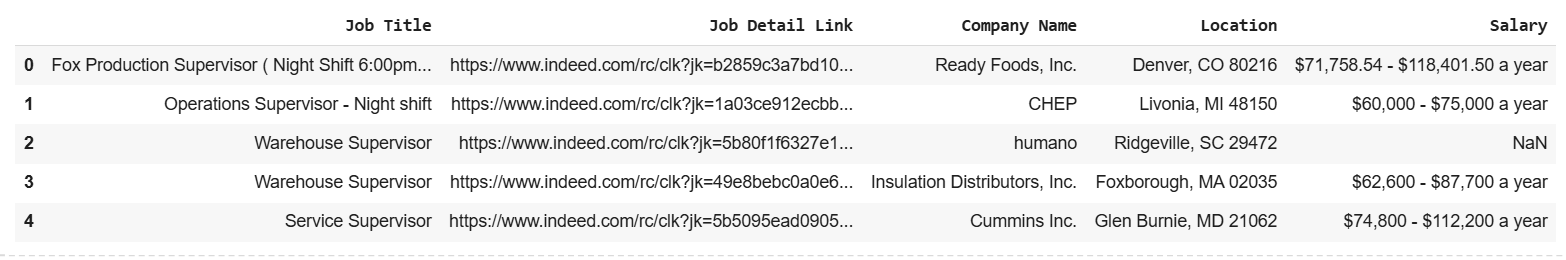

In [1]:

import pandas as pd


# ✅ Load the dataset into a Pandas DataFrame
df = pd.read_csv("indeed_job_listings.csv")

# ✅ Display the first few rows
df.head()


,Job Title,Job Detail Link,Company Name,Location,Salary
0,Fox Production Supervisor ( Night Shift 6:00pm...,https://www.indeed.com/rc/clk?jk=b2859c3a7bd10...,"Ready Foods, Inc.","Denver, CO 80216","$71,758.54 - $118,401.50 a year"
1,Operations Supervisor - Night shift,https://www.indeed.com/rc/clk?jk=1a03ce912ecbb...,CHEP,"Livonia, MI 48150","$60,000 - $75,000 a year"
2,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=5b80f1f6327e1...,humano,"Ridgeville, SC 29472",NaN
3,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=49e8bebc0a0e6...,"Insulation Distributors, Inc.","Foxborough, MA 02035","$62,600 - $87,700 a year"
4,Service Supervisor,https://www.indeed.com/rc/clk?jk=5b5095ead0905...,Cummins Inc.,"Glen Burnie, MD 21062","$74,800 - $112,200 a year"


Problem Statement2:
Now that we have extracted indeed_job_listings into a Pandas DataFrame, we need to store this data in an SQL database for future analysis.

* ✅ Create a database named jobs_database.db.
* ✅ Create a table named Jobs and Insert the DataFrame (df) into SQL in a structured format using df.to_sql() method.
* ✅ If the table already exists, replace it with new data.

Expected output:

✅ Data has been successfully inserted into the 'Jobs' table.

In [3]:
import sqlite3

# ✅ Connect to SQLite database (or create if it doesn’t exist)
conn = sqlite3.connect("jobs_database.db")

# ✅ Store DataFrame in SQL database (Replace if table exists)
df.to_sql("Jobs", conn, if_exists='replace', index=False)

# ✅ Commit changes and close connection
conn.commit()
conn.close()

print("✅ Data has been successfully inserted into the 'Jobs' table.")


✅ Data has been successfully inserted into the 'Jobs' table.


Problem Statement3:
After storing the job listings dataset into an SQL database (jobs_database.db), we need to retrieve and display all job records from the SQL table.

* ✅ Connect to the SQLite database.
* ✅ Fetch all job listings stored in the job_listings table.
* ✅ Load the retrieved data into a Pandas DataFrame.
* ✅ Display the first few rows to verify the retrieval.

Expected output:
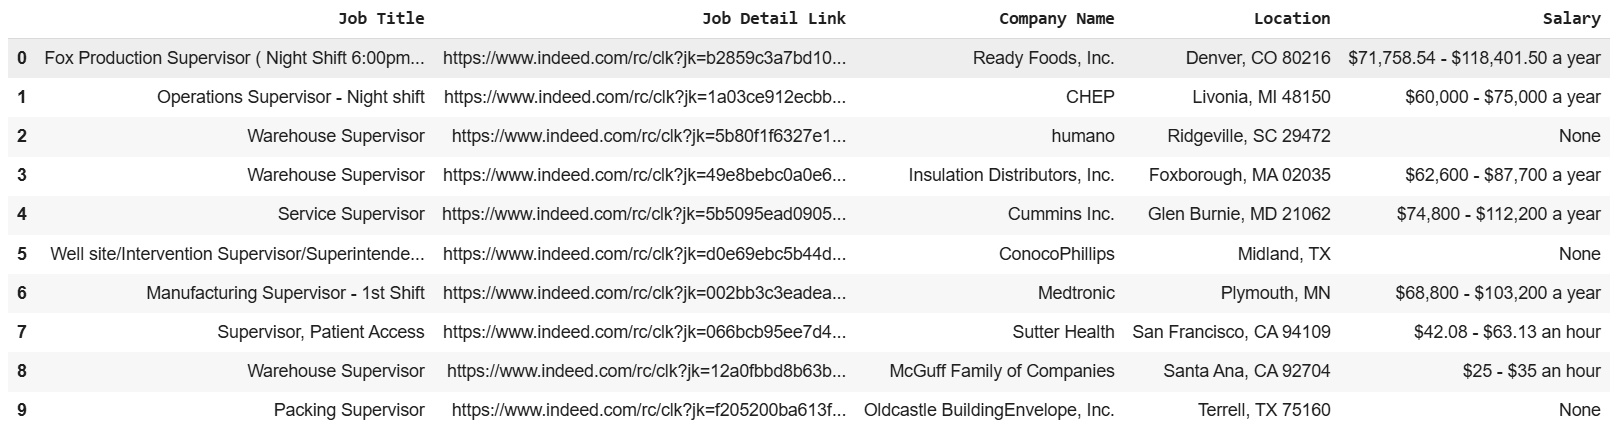


In [4]:
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("jobs_database.db")

# ✅ Retrieve all job listings from the SQL table

df_sql = pd.read_sql("SELECT * FROM Jobs", conn)

# ✅ Close connection
conn.close()

# ✅ Display the first few rows of the retrieved dataset
df_sql


,Job Title,Job Detail Link,Company Name,Location,Salary
0,Fox Production Supervisor ( Night Shift 6:00pm...,https://www.indeed.com/rc/clk?jk=b2859c3a7bd10...,"Ready Foods, Inc.","Denver, CO 80216","$71,758.54 - $118,401.50 a year"
1,Operations Supervisor - Night shift,https://www.indeed.com/rc/clk?jk=1a03ce912ecbb...,CHEP,"Livonia, MI 48150","$60,000 - $75,000 a year"
2,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=5b80f1f6327e1...,humano,"Ridgeville, SC 29472",None
3,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=49e8bebc0a0e6...,"Insulation Distributors, Inc.","Foxborough, MA 02035","$62,600 - $87,700 a year"
4,Service Supervisor,https://www.indeed.com/rc/clk?jk=5b5095ead0905...,Cummins Inc.,"Glen Burnie, MD 21062","$74,800 - $112,200 a year"
5,Well site/Intervention Supervisor/Superintende...,https://www.indeed.com/rc/clk?jk=d0e69ebc5b44d...,ConocoPhillips,"Midland, TX",None
6,Manufacturing Supervisor - 1st Shift,https://www.indeed.com/rc/clk?jk=002bb3c3eadea...,Medtronic,"Plymouth, MN","$68,800 - $103,200 a year"
7,"Supervisor, Patient Access",https://www.indeed.com/rc/clk?jk=066bcb95ee7d4...,Sutter Health,"San Francisco, CA 94109",$42.08 - $63.13 an hour
8,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=12a0fbbd8b63b...,McGuff Family of Companies,"Santa Ana, CA 92704",$25 - $35 an hour
9,Packing Supervisor,https://www.indeed.com/rc/clk?jk=f205200ba613f...,"Oldcastle BuildingEnvelope, Inc.","Terrell, TX 75160",None


Problem Statement4:
We need to find which companies have posted the most job listings in our database. This will help us:

* ✅ Identify the top hiring companies.
* ✅ Analyze which companies are actively recruiting.
* ✅ Understand job availability in different companies.


1️⃣ Group jobs by company name.
2️⃣ Count the number of jobs posted by each company.
3️⃣ Sort the results in descending order to show the most active hiring companies first.

Expected output:

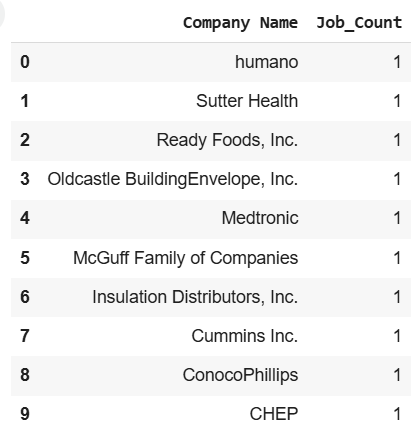



In [5]:
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("jobs_database.db")

# ✅ Count jobs per company from the 'Jobs' table
df_jobs_per_company = pd.read_sql(
    '''
    SELECT "Company Name", COUNT(*) AS Job_Count
    FROM Jobs
    GROUP BY "Company Name"
    ORDER BY Job_Count DESC
    ''',
    conn
)

# ✅ Close connection
conn.close()

# ✅ Display the top 10 companies with the most job listings
df_jobs_per_company.head(10)


,Company Name,Job_Count
0,humano,1
1,Sutter Health,1
2,"Ready Foods, Inc.",1
3,"Oldcastle BuildingEnvelope, Inc.",1
4,Medtronic,1
5,McGuff Family of Companies,1
6,"Insulation Distributors, Inc.",1
7,Cummins Inc.,1
8,ConocoPhillips,1
9,CHEP,1


Problem Statement5:
In the problem statement4 using the same variable where u have written the query  We need to create a bar chart showing the number of jobs per company to identify the top hiring companies.

* ✅ Count the number of job listings per company.
* ✅ Sort companies by the highest number of job postings.
* ✅ Plot a bar chart to visualize the data.

This will help us quickly see which companies are hiring the most.

Expected output:

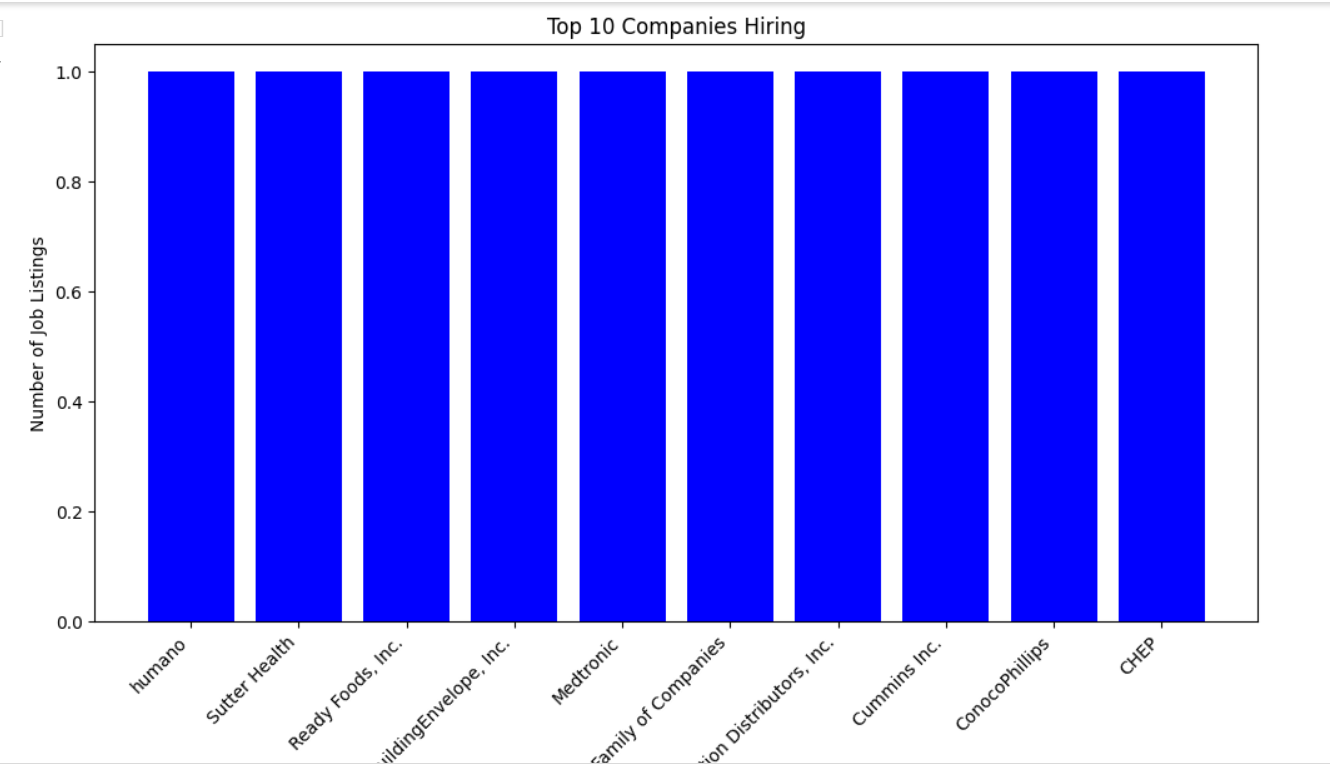

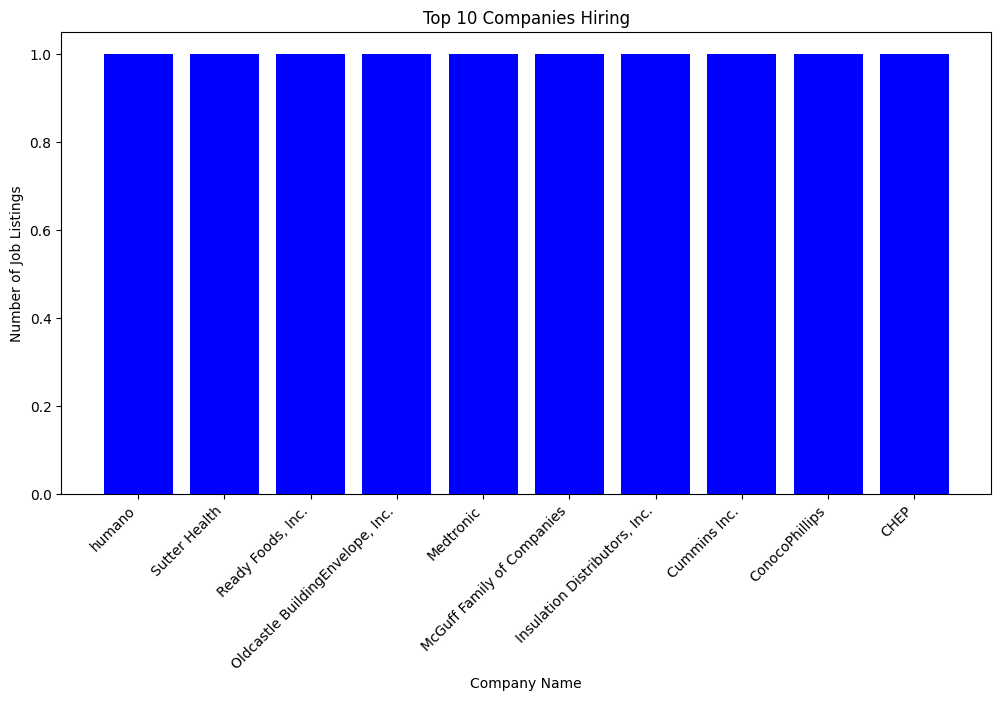

In [6]:
import matplotlib.pyplot as plt
# ✅ Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_jobs_per_company["Company Name"], df_jobs_per_company["Job_Count"], color="blue")
plt.xlabel("Company Name")
plt.ylabel("Number of Job Listings")
plt.title("Top 10 Companies Hiring")
plt.xticks(rotation=45, ha="right")
plt.show()

Problem Statement6:
Retrieve all jobs available in San Francisco, CA 94109 from the database.

* ✅ Filter jobs where the location is exactly "San Francisco, CA 94109".
* ✅ Display relevant job details: Job Title, Company Name, Location, and Salary.
* ✅ Ensure the results include only jobs in this specific location.

This will help job seekers find opportunities specifically in San Francisco, CA 94109.

Expected output:

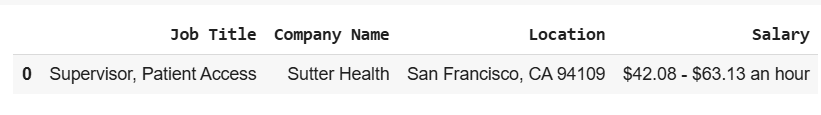


In [7]:
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("jobs_database.db")

# ✅ Retrieve jobs where location is "San Francisco, CA 94109"
df_sf_jobs = pd.read_sql(
    '''
    SELECT "Job Title", "Company Name", "Location", "Salary"
    FROM Jobs
    WHERE "Location" = 'San Francisco, CA 94109'
    ''',
    conn
)

# ✅ Close connection
conn.close()

# ✅ Display the jobs in San Francisco, CA 94109
df_sf_jobs.head(10)


,Job Title,Company Name,Location,Salary
0,"Supervisor, Patient Access",Sutter Health,"San Francisco, CA 94109",$42.08 - $63.13 an hour


Problem Statement7:
Many job listings do not mention salary details, making it harder for job seekers to compare compensation.
We need to find out how many jobs have missing salary information in our dataset.

* ✅ Identify jobs where the Salary column is empty or None using this method (
   WHERE "Salary" IS NULL OR "Salary" = '' )
* ✅ Count the total number of such job listings using len() and print using formatted string.
* ✅ Retrieve job details for missing salary cases.

Expected output:

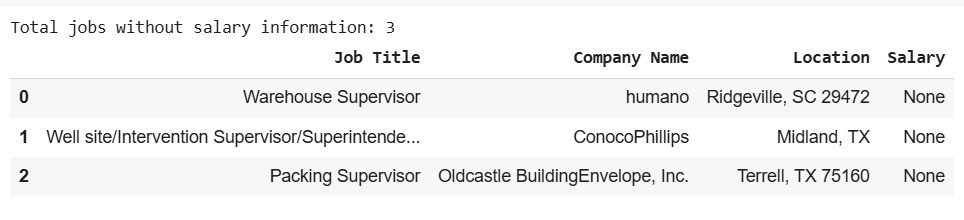

In [8]:
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("jobs_database.db")

# ✅ Retrieve jobs where salary is missing (NULL or empty string)
df_missing_salary = pd.read_sql(
    '''
    SELECT "Job Title", "Company Name", "Location", "Salary"
    FROM Jobs
    WHERE "Salary" IS NULL OR "Salary" = ''
    ''',
    conn
)

# ✅ Close connection
conn.close()

# ✅ Display the total number of jobs missing salary details
print(f"Total jobs without salary information: {len(df_missing_salary)}")

# ✅ Display the first few rows of jobs with missing salaries
df_missing_salary.head(10)


Total jobs without salary information: 3


,Job Title,Company Name,Location,Salary
0,Warehouse Supervisor,humano,"Ridgeville, SC 29472",None
1,Well site/Intervention Supervisor/Superintende...,ConocoPhillips,"Midland, TX",None
2,Packing Supervisor,"Oldcastle BuildingEnvelope, Inc.","Terrell, TX 75160",None



🔹 Problem Statement8:
Analyzing Job Distribution by Location Job availability varies by location, and understanding which cities or states have the most job listings can help job seekers target the right locations and companies plan their hiring strategies.

* ✅ Count the number of job listings in each location.
* ✅ Identify areas with the highest job opportunities.
* ✅ Visualize the distribution using a pie chart to show the percentage of jobs in different locations.

Expected output:
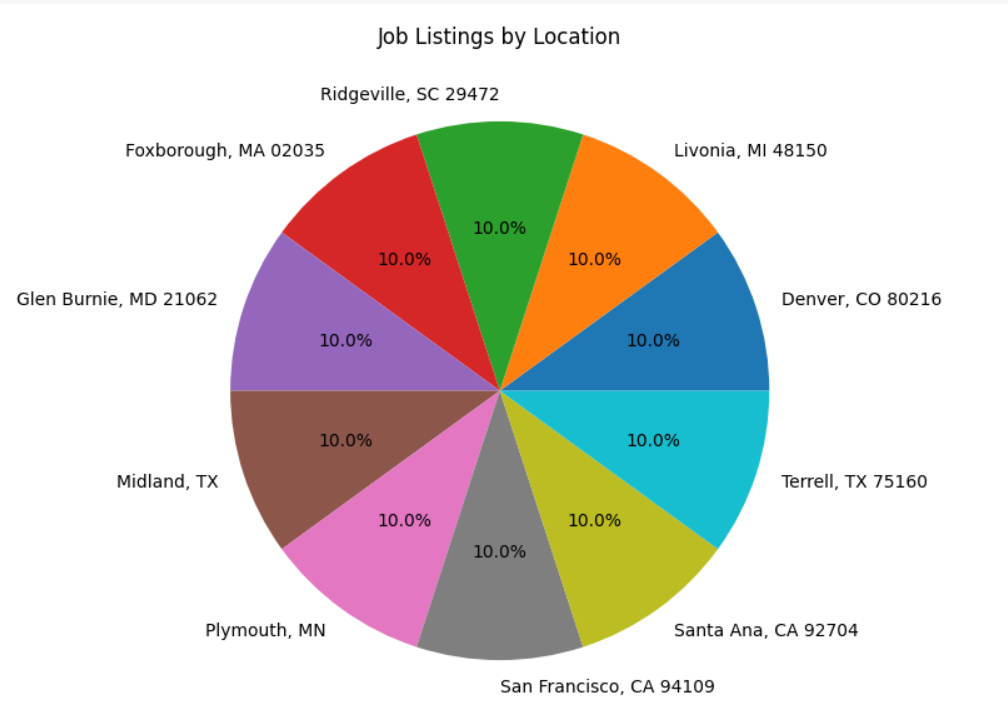


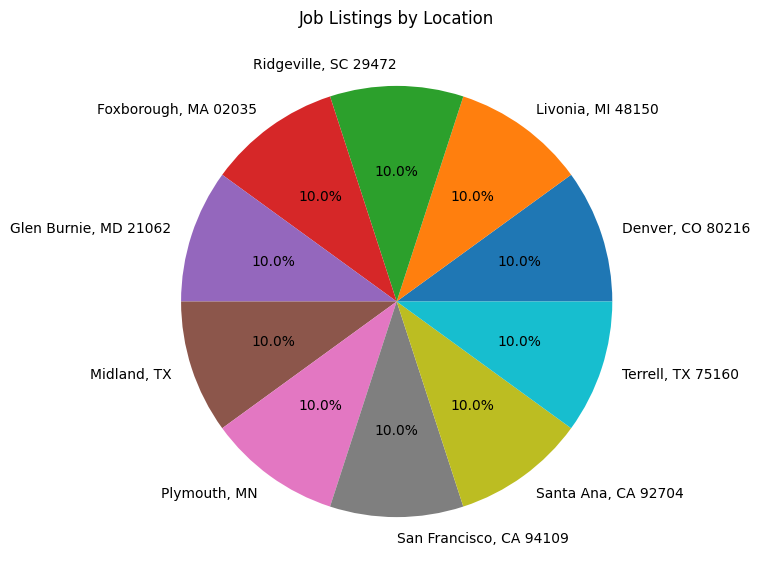

In [9]:
# ✅ Count jobs by location
df_location = df["Location"].value_counts()  # Top 5 locations

# ✅ Plot pie chart
df_location.plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))
plt.title("Job Listings by Location")
plt.ylabel("")  # Remove default label
plt.show()
